In [ ]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Any
import sys
import os

# extra (for functions and plotting)
from readout_simulator.noise_models import CorrelatedNoise
import readout_simulator.helper_functions as hf
from matplotlib.ticker import MaxNLocator, ScalarFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes  
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import matplotlib.patheffects as pe

# Add the src directory to the path
sys.path.append("../src/")

try:
    from readout_simulator import (
        GeometricQuantumDotSystem,
        RLC_sensor, 
        JAXReadoutSimulator,
        OU_noise, 
        OverFNoise
    )
    print("✓ Successfully imported ReadSpyn components")
except ImportError as e:
    print(f"✗ Failed to import ReadSpyn components: {e}")
    sys.exit(1)


✓ Successfully imported ReadSpyn components


# All functions 

In [ ]:
# ============================================================
# A) Integration & basic preprocessing utilities
# ============================================================

def _integrate_last_cummean(M):
    """
    Integrate time series by cumulative mean and take the final value.

    Parameters
    ----------
    M : ndarray, shape (N, T)
        Matrix of N traces with T time steps.

    Returns
    -------
    ndarray, shape (N,)
        One scalar per trace: the cumulative mean at the last time step.
    """
    T = M.shape[1]
    return (np.cumsum(M, axis=-1) / np.arange(1, T+1))[:, -1]


def _demean_per_class(I0, Q0, I1, Q1):
    """
    Demean I/Q features *within each class* independently.

    Parameters
    ----------
    I0, Q0 : ndarray, shape (N0,)
        Features for class 0.
    I1, Q1 : ndarray, shape (N1,)
        Features for class 1.

    Returns
    -------
    I0m, Q0m, I1m, Q1m : ndarrays
        Demeaned features (class-wise means subtracted).
    """
    I0m, Q0m = I0 - I0.mean(), Q0 - Q0.mean()
    I1m, Q1m = I1 - I1.mean(), Q1 - Q1.mean()
    return I0m, Q0m, I1m, Q1m


def _zscore_together(I0, Q0, I1, Q1):
    """
    Z-score I and Q using statistics computed on both classes together.

    Parameters
    ----------
    I0, Q0 : ndarray, shape (N0,)
        Features for class 0.
    I1, Q1 : ndarray, shape (N1,)
        Features for class 1.

    Returns
    -------
    I0z, Q0z, I1z, Q1z : ndarrays
        Standardized features with shared mean/std per channel.
    """
    I = np.concatenate([I0, I1]); Q = np.concatenate([Q0, Q1])
    Imu, Isd = I.mean(), I.std() + 1e-12
    Qmu, Qsd = Q.mean(), Q.std() + 1e-12
    return ( (I0-Imu)/Isd, (Q0-Qmu)/Qsd, (I1-Imu)/Isd, (Q1-Qmu)/Qsd )


# ============================================================
# B) LDA thresholding on 2D I/Q + plotting
# ============================================================

def threshold_clusters(I0, Q0, I1, Q1, plot_ax=None):
    """
    Do 2D LDA on (I,Q), scan thresholds on the 1D score, and (optionally) plot the decision line.

    Parameters
    ----------
    I0, Q0 : ndarray, shape (N0,)
        Class-0 features.
    I1, Q1 : ndarray, shape (N1,)
        Class-1 features.
    plot_ax : matplotlib.axes.Axes or None
        If provided, draws the decision boundary and shows the fidelity.

    Returns
    -------
    dict with keys:
        'fidelity' : float
            1 - minimum classification error using the scanned threshold.
        'threshold' : float
            Best threshold in LDA score space.
        'w' : ndarray, shape (2,)
            LDA projection vector.
        'scores' : ndarray, shape (N0+N1,)
            Projected 1D scores for all samples.
        'y' : ndarray, shape (N0+N1,)
            Ground-truth labels (0/1).
        'pred' : ndarray, shape (N0+N1,)
            Predictions at the chosen threshold (0/1).
    """
    X0 = np.column_stack([I0, Q0])
    X1 = np.column_stack([I1, Q1])
    X  = np.vstack([X0, X1])
    y  = np.concatenate([np.zeros(len(X0), int), np.ones(len(X1), int)])

    mu0, mu1 = X0.mean(axis=0), X1.mean(axis=0)
    C0, C1   = np.cov(X0, rowvar=False), np.cov(X1, rowvar=False)
    n0, n1   = len(X0), len(X1)
    S = ((n0-1)*C0 + (n1-1)*C1) / (n0+n1-2)
    w = np.linalg.pinv(S) @ (mu1 - mu0)

    scores = X @ w
    uniq = np.unique(scores)
    if len(uniq) == 1:
        thr = uniq[0]; pred = np.zeros_like(y); err = min((y==0).mean(), (y==1).mean())
    else:
        ths = (uniq[:-1] + uniq[1:]) / 2.0
        best = min(((scores>=t).astype(int)!=y).mean() for t in ths)
        # re-find the threshold that gives min error (two passes keep code simple)
        err, thr = 1.0, ths[0]
        for t in ths:
            e = ((scores>=t).astype(int)!=y).mean()
            if e < err: err, thr = e, t
        pred = (scores >= thr).astype(int)

    if plot_ax is not None:
        xmin, xmax = plot_ax.get_xlim()
        if abs(w[1]) > 1e-12:
            I_line = np.array([xmin, xmax])
            Q_line = (thr - w[0]*I_line) / w[1]
            plot_ax.plot(I_line, Q_line, color='k', lw=1.5)
        else:
            plot_ax.axvline(thr / (w[0]+1e-12), color='k', lw=1.5)
        plot_ax.text(0.02, 0.02, f'F={1-err:.3f}', transform=plot_ax.transAxes)

    return {'fidelity': 1.0 - err, 'threshold': thr, 'w': w, 'scores': scores, 'y': y, 'pred': pred}


def plot_and_threshold_sensor(results, sensor_idx=0,
                              use_cummean=True,
                              demean=False, zscore=False,
                              colors=('tab:red','tab:blue'),
                              title=None):
    """
    Convenience wrapper: extract (I,Q) features for one sensor, optionally preprocess, plot clusters, and LDA-threshold.

    Parameters
    ----------
    results : dict
        Simulator output containing 'sensor_results' with I/Q arrays.
    sensor_idx : int
        Which sensor to visualize (0-based).
    use_cummean : bool
        If True, use cumulative-mean integration; else use simple mean over time.
    demean : bool
        If True, apply class-wise demeaning to I/Q.
    zscore : bool
        If True, apply joint z-scoring to I/Q across both classes.
    colors : tuple(str, str)
        Colors for (class 0, class 1) scatter.
    title : str or None
        Plot title. If None, uses "Sensor {sensor_idx}".

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
        The created figure and axes.
    out : dict
        Output from `threshold_clusters`, including fidelity and decision info.
    """
    # 1) pull time-series and integrate to features
    I0 = results['sensor_results'][sensor_idx]['I'][0]
    Q0 = results['sensor_results'][sensor_idx]['Q'][0]
    I1 = results['sensor_results'][sensor_idx]['I'][1]
    Q1 = results['sensor_results'][sensor_idx]['Q'][1]
    integ = _integrate_last_cummean if use_cummean else np.mean
    I0f, Q0f = integ(I0), integ(Q0)
    I1f, Q1f = integ(I1), integ(Q1)

    # 2) optional preprocessing
    if demean:
        I0f, Q0f, I1f, Q1f = _demean_per_class(I0f, Q0f, I1f, Q1f)
    if zscore:
        I0f, Q0f, I1f, Q1f = _zscore_together(I0f, Q0f, I1f, Q1f)

    # 3) plot
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    ax.scatter(I0f, Q0f, s=16, alpha=0.35, color=colors[0], label='state 0')
    ax.scatter(I1f, Q1f, s=16, alpha=0.35, color=colors[1], label='state 1')
    ax.set_xlabel('I (a.u.)'); ax.set_ylabel('Q (a.u.)')
    ax.set_title(f"Sensor {sensor_idx}" if title is None else title)
    ax.axis('equal'); ax.legend(loc='best', frameon=False)

    # 4) threshold & decision line
    out = threshold_clusters(I0f, Q0f, I1f, Q1f, plot_ax=ax)
    plt.tight_layout()
    return fig, ax, out


# ============================================================
# C) Geometry helper (rotation)
# ============================================================

def rotate_dot_positions(dot_positions, angle_deg, center=(50.0, 0.0)):
    """
    Rotate a set of 2D points about a pivot.

    Parameters
    ----------
    dot_positions : ndarray, shape (N, 2)
        Original (x,y) coordinates of N dots.
    angle_deg : float
        Rotation angle in degrees (positive = counterclockwise).
    center : tuple(float, float)
        Pivot point (cx, cy).

    Returns
    -------
    ndarray, shape (N, 2)
        Rotated (x,y) coordinates.
    """
    pts = np.asarray(dot_positions, dtype=float)
    cx, cy = center
    th = np.deg2rad(angle_deg)
    R = np.array([[np.cos(th), -np.sin(th)],
                  [np.sin(th),  np.cos(th)]])
    return (pts - np.array([cx, cy])) @ R.T + np.array([cx, cy])


# ============================================================
# D) Feature extraction for fidelity (per-sensor and combined 4D)
# ============================================================

def _features_per_sensor(results, sidx):
    """
    Build 2D features [I, Q] for a single sensor by integrating each shot.

    Parameters
    ----------
    results : dict
        Simulator output with 'sensor_results'.
    sidx : int
        Sensor index.

    Returns
    -------
    X : ndarray, shape (N0+N1, 2)
        Stacked features for both classes.
    y : ndarray, shape (N0+N1,)
        Labels (0 for first state block, 1 for second).
    """
    I0 = _integrate_last_cummean(results['sensor_results'][sidx]['I'][0])
    Q0 = _integrate_last_cummean(results['sensor_results'][sidx]['Q'][0])
    I1 = _integrate_last_cummean(results['sensor_results'][sidx]['I'][1])
    Q1 = _integrate_last_cummean(results['sensor_results'][sidx]['Q'][1])
    X0 = np.column_stack([I0, Q0])
    X1 = np.column_stack([I1, Q1])
    X  = np.vstack([X0, X1])
    y  = np.concatenate([np.zeros(len(X0), int), np.ones(len(X1), int)])
    return X, y


def _features_combined(results):
    """
    Build 4D features by concatenating [I,Q] from sensor 0 and sensor 1.

    Parameters
    ----------
    results : dict
        Simulator output with 'sensor_results'.

    Returns
    -------
    X : ndarray, shape (N0+N1, 4)
        4D features [I0,Q0,I1,Q1] per shot.
    y : ndarray, shape (N0+N1,)
        Labels (0/1) per shot.
    """
    I0s0 = _integrate_last_cummean(results['sensor_results'][0]['I'][0])
    Q0s0 = _integrate_last_cummean(results['sensor_results'][0]['Q'][0])
    I0s1 = _integrate_last_cummean(results['sensor_results'][1]['I'][0])
    Q0s1 = _integrate_last_cummean(results['sensor_results'][1]['Q'][0])
    X0 = np.column_stack([I0s0, Q0s0, I0s1, Q0s1])

    I1s0 = _integrate_last_cummean(results['sensor_results'][0]['I'][1])
    Q1s0 = _integrate_last_cummean(results['sensor_results'][0]['Q'][1])
    I1s1 = _integrate_last_cummean(results['sensor_results'][1]['I'][1])
    Q1s1 = _integrate_last_cummean(results['sensor_results'][1]['Q'][1])
    X1 = np.column_stack([I1s0, Q1s0, I1s1, Q1s1])

    X = np.vstack([X0, X1])
    y = np.concatenate([np.zeros(len(X0), int), np.ones(len(X1), int)])
    return X, y


# ============================================================
# E) LDA fidelity (numeric only; used for 2D or 4D X)
# ============================================================

def _pooled_cov(X0, X1):
    """
    Compute the unbiased pooled covariance matrix of two classes.

    Parameters
    ----------
    X0, X1 : ndarray, shape (N0, D), (N1, D)
        Feature matrices for the two classes.

    Returns
    -------
    ndarray, shape (D, D)
        Pooled covariance.
    """
    C0 = np.cov(X0, rowvar=False, bias=False)
    C1 = np.cov(X1, rowvar=False, bias=False)
    n0, n1 = len(X0), len(X1)
    return ((n0-1)*C0 + (n1-1)*C1) / (n0+n1-2)


def _lda_fidelity(X, y):
    """
    Project onto 1D via LDA, scan thresholds, and return fidelity.

    Parameters
    ----------
    X : ndarray, shape (N, D)
        Features.
    y : ndarray, shape (N,)
        Labels (0/1).

    Returns
    -------
    float
        Maximum single-threshold accuracy (1 - min error).
    """
    X0, X1 = X[y==0], X[y==1]
    mu0, mu1 = X0.mean(axis=0), X1.mean(axis=0)
    S = _pooled_cov(X0, X1)
    w = np.linalg.pinv(S) @ (mu1 - mu0)
    scores = X @ w
    uniq = np.unique(scores)
    if len(uniq) <= 1:
        err = min((y==0).mean(), (y==1).mean())
        return 1.0 - float(err)
    ths = (uniq[:-1] + uniq[1:]) / 2.0
    err = min(((scores >= t).astype(int) != y).mean() for t in ths)
    return 1.0 - float(err)


# ============================================================
# F) Rotation-only benchmarking (per-sensor + combined)
# ============================================================

def benchmark_rotation_fidelity_multi(simulator_factory,        # fn(dot_positions, angle_deg)->simulator
                                      dot_positions, angles_deg,
                                      charge_state_a, charge_state_b,
                                      times, params, noise_model,
                                      n_realizations=2000, key=jax.random.PRNGKey(0)):
    """
    Sweep rotation angles and compute fidelities for sensor 0, sensor 1, and 4D combined.

    Parameters
    ----------
    simulator_factory : callable
        simulator_factory(dot_positions, angle_deg) -> simulator.
    dot_positions : ndarray, shape (N,2)
        Dot coordinates.
    angles_deg : sequence of float
        Rotation angles to evaluate.
    charge_state_a, charge_state_b : array-like
        Two charge-state vectors to simulate.
    times : jnp.ndarray
        Time grid for the simulator.
    params : dict
        Simulator parameters (includes 't_end', 'snr', etc.).
    noise_model : object or None
        Noise model object to pass to precompute_noise, or None.
    n_realizations : int
        Number of noise realizations.
    key : jax.random.PRNGKey
        RNG key.

    Returns
    -------
    f_s0, f_s1, f_comb : ndarrays, shape (len(angles_deg),)
        Fidelities for sensor 0, sensor 1, and combined (4D).
    """
    f_s0, f_s1, f_comb = [], [], []
    for ang in angles_deg:
        sim = simulator_factory(dot_positions, ang)
        cs  = jnp.stack([jnp.array(charge_state_a), jnp.array(charge_state_b)])

        key, sub = jax.random.split(key)
        if noise_model is not None:
            sim.precompute_noise(sub, times, n_realizations, noise_model)
            key, sub = jax.random.split(key)

        results = sim.run_simulation(cs, times, params, sub)

        # per-sensor fidelities
        X0, y0 = _features_per_sensor(results, 0)
        X1, y1 = _features_per_sensor(results, 1)
        f_s0.append(_lda_fidelity(X0, y0))
        f_s1.append(_lda_fidelity(X1, y1))

        # combined (4D)
        Xc, yc = _features_combined(results)
        f_comb.append(_lda_fidelity(Xc, yc))

    return np.array(f_s0), np.array(f_s1), np.array(f_comb)


def plot_rotation_fidelity_multi(angles_deg, f0, f1, fc, title='Thresholding accuracy vs rotation'):
    """
    Plot rotation-angle sweep of single-shot fidelity for both sensors and combined 4D.

    Parameters
    ----------
    angles_deg : sequence of float
        Angles on x-axis.
    f0, f1, fc : sequence of float
        Fidelities for sensor 0, sensor 1, and combined (4D).
    title : str
        Plot title.

    Returns
    -------
    fig, ax : matplotlib Figure, Axes
        The created figure and axes.
    """
    fig, ax = plt.subplots(figsize=(6.4, 3.6))
    ax.plot(angles_deg, f0, '-o', ms=4, label='Sensor 0')
    ax.plot(angles_deg, f1, '-o', ms=4, label='Sensor 1')
    ax.plot(angles_deg, fc, '-o', ms=4, label='Combined (4D)')
    ax.set_xlabel('rotation (deg)')
    ax.set_ylabel('single-shot fidelity')
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)
    ax.set_title(title)
    ax.legend(frameon=False)
    plt.tight_layout()
    return fig, ax


def simulator_factory(dot_positions, angle_deg, center=(50.0, 0.0)):
    """
    Minimal factory for rotation-only experiments (uses globals from the notebook).

    Returns
    -------
    simulator : JAXReadoutSimulator
        Simulator instance for the rotated dot geometry and current sensor positions.
    """
    dots_rot = rotate_dot_positions(dot_positions, angle_deg, center=center)
    geo = GeometricQuantumDotSystem(dots_rot, sensor_positions, C0=1e-15, alpha=0.8, beta=0.005)
    s0 = RLC_sensor(params_resonator, params_coulomb_peak, c_noise)
    s1 = RLC_sensor(params_resonator, params_coulomb_peak, c_noise)
    return JAXReadoutSimulator(geo.dot_system, [s0, s1])


# ============================================================
# G) Layout visualization (inset) & rotation snapshots
# ============================================================

def plot_layout_inset(dot_positions, sensor_positions, angle_deg=0.0,
                      center=(50.0, 0.0), ax=None,
                      theme='light', show_labels=False, show_pivot=True,
                      dot_size=26, sensor_size=72, lw=1.1, annot_deg=True):
    """
    Draw a minimal, tickless snapshot of the layout (good as an inset).

    Parameters
    ----------
    dot_positions : ndarray, shape (N,2)
        Original dot positions (will be rotated inside).
    sensor_positions : ndarray, shape (M,2)
        Sensor positions (drawn as triangles).
    angle_deg : float
        Rotation angle for the dots.
    center : tuple
        Pivot point for rotation.
    ax : matplotlib Axes or None
        Axes to draw on; creates one if None.
    theme : {'light','dark'}
        Color theme.
    show_labels : bool
        If True, annotate dots as D0..DN-1.
    show_pivot : bool
        If True, show center point.
    dot_size, sensor_size : float
        Marker sizes.
    lw : float
        Edge linewidth for markers.
    annot_deg : bool
        If True, annotate the angle in the top-left.

    Returns
    -------
    ax : matplotlib Axes
        The axes used for drawing.
    """
    # --- theme ---
    if theme == 'dark':
        bg, fg, gridc = '#0f1116', '#e8eaed', '#2a2e39'
    else:
        bg, fg, gridc = 'white', '#111', '#e6e6e6'

    # --- rotate dots ---
    pts = np.asarray(dot_positions, float)
    cx, cy = center
    th = np.deg2rad(angle_deg)
    R  = np.array([[np.cos(th), -np.sin(th)],[np.sin(th), np.cos(th)]])
    dots = (pts - [cx, cy]) @ R.T + [cx, cy]
    sens = np.asarray(sensor_positions, float)

    if ax is None:
        fig, ax = plt.subplots(figsize=(2.0, 2.0))
    ax.set_facecolor(bg)

    # sensors (triangles with subtle shadow)
    eff = [pe.withSimplePatchShadow(offset=(0.5,-0.5), shadow_rgbFace='0.3', alpha=0.25)]
    ax.scatter(sens[:,0], sens[:,1], marker='^', s=sensor_size, color=fg,
               edgecolor=fg, linewidths=lw, zorder=3, path_effects=eff)

    # dots (color cycle)
    palette = ['#2563eb', '#f59e0b', '#22c55e', '#ef4444']  # blue, amber, green, red
    for i, (x,y) in enumerate(dots):
        ax.scatter([x],[y], s=dot_size, color=palette[i%4], edgecolor=fg, linewidths=0.7,
                   zorder=4, path_effects=[pe.withSimplePatchShadow(offset=(0.6,-0.6),
                   shadow_rgbFace='0.2', alpha=0.25)])
        if show_labels:
            ax.text(x, y, f"D{i}", color=fg, fontsize=7, ha='left', va='bottom', alpha=0.9)

    # pivot
    if show_pivot:
        ax.scatter([cx],[cy], s=14, color=fg, alpha=0.6, zorder=2)

    # tight limits
    all_x = np.concatenate([sens[:,0], dots[:,0], [cx]])
    all_y = np.concatenate([sens[:,1], dots[:,1], [cy]])
    span  = max(all_x.max()-all_x.min(), all_y.max()-all_y.min(), 1.0)
    pad   = 0.14 * span
    ax.set_xlim(all_x.min()-pad, all_x.max()+pad)
    ax.set_ylim(all_y.min()-pad, all_y.max()+pad)
    ax.set_aspect('equal', adjustable='box')

    # clean axes
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)

    # angle annotation
    if annot_deg:
        ax.text(0.02, 0.95, f'{angle_deg:.0f}°', transform=ax.transAxes,
                color=fg, fontsize=8, ha='left', va='top',
                bbox=dict(boxstyle='round,pad=0.2', facecolor=bg, edgecolor='none', alpha=0.6))
    return ax


def plot_rotation_snapshots(dot_positions, sensor_positions, angles_deg,
                            center=(50.0, 0.0), ncols=6, figsize=(10, 4),
                            theme='light', show_labels=False, show_pivot=False,
                            dot_size=26, sensor_size=72, lw=1.1):
    """
    Make a grid of small snapshots for selected rotation angles.

    Returns
    -------
    fig : matplotlib Figure
    axes : ndarray of Axes
        Axes for the populated subplots (flattened).
    """
    angles_deg = list(angles_deg)
    n = len(angles_deg)
    ncols = max(1, min(ncols, n))
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    # set figure bg to match theme
    if theme == 'dark':
        fig.patch.set_facecolor('#0f1116')
    else:
        fig.patch.set_facecolor('white')

    for i, ang in enumerate(angles_deg):
        plot_layout_inset(dot_positions, sensor_positions, angle_deg=ang, center=center,
                          ax=axes[i], theme=theme, show_labels=show_labels,
                          show_pivot=show_pivot, dot_size=dot_size,
                          sensor_size=sensor_size, lw=lw, annot_deg=True)

    # hide unused
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    fig.tight_layout(pad=0.6, w_pad=0.6, h_pad=0.6)
    return fig, axes[:n]


# ============================================================
# H) Sensor x-shift utilities and sweeps
# ============================================================

def shift_sensor_positions_x(sensor_positions, dx, inplace=False):
    """
    Shift each sensor's x-position (individually or all the same).

    Parameters
    ----------
    sensor_positions : ndarray, shape (M,2)
        Current sensor (x,y) positions.
    dx : float or ndarray, shape (M,)
        If float: add the same dx to all sensors.
        If array: per-sensor dx to add to x.
    inplace : bool
        If True, modify the input array in-place.

    Returns
    -------
    ndarray, shape (M,2)
        Updated sensor positions (same object if inplace=True).
    """
    sp = sensor_positions if inplace else np.array(sensor_positions, dtype=float, copy=True)
    dx = np.array(dx, dtype=float)
    if dx.ndim == 0:
        sp[:, 0] += dx
    else:
        if len(dx) != sp.shape[0]:
            raise ValueError(f"dx length {len(dx)} must match number of sensors {sp.shape[0]}")
        sp[:, 0] += dx
    return sp


def set_sensor_positions_x(sensor_positions, x_targets, inplace=False):
    """
    Set absolute x-positions for sensors.

    Parameters
    ----------
    sensor_positions : ndarray, shape (M,2)
        Current sensor positions.
    x_targets : ndarray, shape (M,)
        Target x positions for each sensor.
    inplace : bool
        If True, modify the input array in-place.

    Returns
    -------
    ndarray, shape (M,2)
        Sensor positions with replaced x-components.
    """
    sp = sensor_positions if inplace else np.array(sensor_positions, dtype=float, copy=True)
    x_targets = np.array(x_targets, dtype=float)
    if len(x_targets) != sp.shape[0]:
        raise ValueError(f"x_targets length {len(x_targets)} must match number of sensors {sp.shape[0]}")
    sp[:, 0] = x_targets
    return sp


def simulator_factory_with_sensors(dot_positions, sensor_positions_local, angle_deg, center=(50.0, 0.0)):
    """
    Factory that accepts explicit sensor positions and a rotation angle.

    Returns
    -------
    simulator : JAXReadoutSimulator
        Simulator for the rotated dots and provided sensors.
    """
    dots_rot = rotate_dot_positions(dot_positions, angle_deg, center=center)
    geo = GeometricQuantumDotSystem(dots_rot, sensor_positions_local, C0=1e-15, alpha=0.8, beta=0.005)
    s0 = RLC_sensor(params_resonator, params_coulomb_peak, c_noise)
    s1 = RLC_sensor(params_resonator, params_coulomb_peak, c_noise)
    return JAXReadoutSimulator(geo.dot_system, [s0, s1])


def _fidelities_from_results(results):
    """
    Convert a single simulation result into three fidelities.

    Returns
    -------
    f0, f1, fc : floats
        Fidelities for sensor 0, sensor 1, and combined (4D).
    """
    X0, y0 = _features_per_sensor(results, 0)
    X1, y1 = _features_per_sensor(results, 1)
    Xc, yc = _features_combined(results)
    f0 = _lda_fidelity(X0, y0)
    f1 = _lda_fidelity(X1, y1)
    fc = _lda_fidelity(Xc, yc)
    return f0, f1, fc


def sweep_sensor_shift_symmetric(dot_positions, base_sensor_positions, dx_values,
                                 charge_state_a, charge_state_b,
                                 times, params, noise_model,
                                 angle_deg=0.0, n_realizations=2000, key=jax.random.PRNGKey(0),
                                 center=(50.0, 0.0)):
    """
    Sweep symmetric x-shifts: sensor0 += dx, sensor1 -= dx, at a fixed rotation angle.

    Returns
    -------
    f0, f1, fc : ndarrays, shape (len(dx_values),)
        Fidelities vs dx for sensor 0, sensor 1, and combined (4D).
    """
    f0, f1, fc = [], [], []
    for dx in dx_values:
        sp = shift_sensor_positions_x(base_sensor_positions, [dx, -dx])
        sim = simulator_factory_with_sensors(dot_positions, sp, angle_deg, center=center)

        key, sub = jax.random.split(key)
        if noise_model is not None:
            sim.precompute_noise(sub, times, n_realizations, noise_model)
            key, sub = jax.random.split(key)

        cs = jnp.stack([jnp.array(charge_state_a), jnp.array(charge_state_b)])
        results = sim.run_simulation(cs, times, params, sub)
        _f0, _f1, _fc = _fidelities_from_results(results)
        f0.append(_f0); f1.append(_f1); fc.append(_fc)
    return np.array(f0), np.array(f1), np.array(fc)


def sweep_sensor_shift_grid(dot_positions, base_sensor_positions, dx0_vals, dx1_vals,
                            charge_state_a, charge_state_b,
                            times, params, noise_model,
                            angle_deg=0.0, n_realizations=1200, key=jax.random.PRNGKey(0),
                            center=(50.0, 0.0)):
    """
    Sweep a 2D grid of independent shifts (dx0 for sensor 0, dx1 for sensor 1) at a fixed angle.

    Returns
    -------
    F0, F1, FC : ndarrays, shape (len(dx0_vals), len(dx1_vals))
        Fidelity heatmaps for sensor 0, sensor 1, and combined (4D).
    """
    F0 = np.zeros((len(dx0_vals), len(dx1_vals)))
    F1 = np.zeros_like(F0)
    FC = np.zeros_like(F0)
    for i, dx0 in enumerate(dx0_vals):
        for j, dx1 in enumerate(dx1_vals):
            sp = shift_sensor_positions_x(base_sensor_positions, [dx0, dx1])
            sim = simulator_factory_with_sensors(dot_positions, sp, angle_deg, center=center)

            key, sub = jax.random.split(key)
            if noise_model is not None:
                sim.precompute_noise(sub, times, n_realizations, noise_model)
                key, sub = jax.random.split(key)

            cs = jnp.stack([jnp.array(charge_state_a), jnp.array(charge_state_b)])
            results = sim.run_simulation(cs, times, params, sub)
            _f0, _f1, _fc = _fidelities_from_results(results)
            F0[i, j], F1[i, j], FC[i, j] = _f0, _f1, _fc
    return F0, F1, FC


def plot_sensor_shift_curves(dx_values, f0, f1, fc, xlabel='symmetric shift dx (x-units)'):
    """
    Plot fidelity vs symmetric sensor shift for both sensors and combined.

    Returns
    -------
    None
    """
    plt.figure(figsize=(6.2,3.6))
    plt.plot(dx_values, f0, '-o', ms=4, label='Sensor 0')
    plt.plot(dx_values, f1, '-o', ms=4, label='Sensor 1')
    plt.plot(dx_values, fc, '-o', ms=4, label='Combined (4D)')
    plt.xlabel(xlabel); plt.ylabel('single-shot fidelity'); plt.ylim(0,1)
    plt.grid(alpha=0.3); plt.legend(frameon=False); plt.tight_layout()


def plot_sensor_shift_heatmaps(dx0_vals, dx1_vals, F0, F1, FC, cmap='viridis'):
    """
    Plot heatmaps of fidelity for independent sensor shifts (dx0, dx1).

    Returns
    -------
    fig : matplotlib Figure
    """
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.3), sharex=True, sharey=True)
    for ax, F, title in zip(axes, (F0, F1, FC), ('Sensor 0', 'Sensor 1', 'Combined (4D)')):
        im = ax.imshow(F.T, origin='lower', aspect='auto', cmap=cmap,
                       extent=[dx0_vals[0], dx0_vals[-1], dx1_vals[0], dx1_vals[-1]],
                       vmin=0.0, vmax=1.0)
        ax.set_title(title); ax.set_xlabel('dx sensor 0'); ax.set_ylabel('dx sensor 1')
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85, label='fidelity')
    fig.tight_layout()
    return fig


# ============================================================
# I) Rotation × shift surface + highlighting + optimal layout
# ============================================================

def sweep_rotation_and_shift(dot_positions, base_sensor_positions,
                             angles_deg, dx_values,
                             charge_state_a, charge_state_b,
                             build_simulator,                  # callable(dots, sensors, angle_deg) -> simulator
                             times, params, noise_model,
                             n_realizations=1200, key=jax.random.PRNGKey(0)):
    """
    Sweep rotation × symmetric x-shift; compute fidelities for each grid point.

    Returns
    -------
    F0, F1, FC : ndarrays, shape (len(angles_deg), len(dx_values))
        Fidelity surfaces for sensor 0, sensor 1, and combined (4D).
    """
    nA, nD = len(angles_deg), len(dx_values)
    F0 = np.zeros((nA, nD))
    F1 = np.zeros((nA, nD))
    FC = np.zeros((nA, nD))

    for ia, ang in enumerate(angles_deg):
        for idd, dx in enumerate(dx_values):
            # symmetric shift: sensor0 += dx, sensor1 -= dx
            sp = np.array(base_sensor_positions, float, copy=True)
            sp[0, 0] += dx
            sp[1, 0] -= dx

            sim = build_simulator(dot_positions, sp, ang)

            key, sub = jax.random.split(key)
            if noise_model is not None:
                sim.precompute_noise(sub, times, n_realizations, noise_model)
                key, sub = jax.random.split(key)

            cs = jnp.stack([jnp.array(charge_state_a), jnp.array(charge_state_b)])
            results = sim.run_simulation(cs, times, params, sub)

            X0, y0 = _features_per_sensor(results, 0)
            X1, y1 = _features_per_sensor(results, 1)
            Xc, yc = _features_combined(results)
            F0[ia, idd] = _lda_fidelity(X0, y0)
            F1[ia, idd] = _lda_fidelity(X1, y1)
            FC[ia, idd] = _lda_fidelity(Xc, yc)

    return F0, F1, FC


def plot_fidelity_surface_3d(angles_deg, dx_values, Z, title='Fidelity vs sensor shift & rotation',
                             elev=28, azim=-135, zlim=(0.0, 1.0)):
    """
    Draw a 3D surface of fidelity vs (dx, angle).

    Parameters
    ----------
    angles_deg : sequence of float
        Rotation angles (y-axis).
    dx_values : sequence of float
        Symmetric sensor x-shifts (x-axis).
    Z : ndarray, shape (len(angles_deg), len(dx_values))
        Fidelity surface.
    title : str
        Plot title.
    elev, azim : float
        View angles for the 3D plot.
    zlim : tuple(float, float)
        Limits for the z-axis.

    Returns
    -------
    fig, ax : matplotlib Figure, 3D Axes
    """
    A, D = np.meshgrid(angles_deg, dx_values, indexing='ij')
    fig = plt.figure(figsize=(7.4, 4.8))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(D, A, Z, cmap='viridis', antialiased=True, linewidth=0)
    ax.set_xlabel('dx (sensor0 +dx, sensor1 -dx)')
    ax.set_ylabel('rotation (deg)')
    ax.set_zlabel('fidelity')
    if zlim is not None:
        ax.set_zlim(*zlim)
    ax.view_init(elev=elev, azim=azim)
    fig.colorbar(surf, shrink=0.7, pad=0.08, label='fidelity')
    ax.set_title(title)
    plt.tight_layout()
    return fig, ax


def build_simulator(dot_positions, sensor_positions_local, angle_deg):
    """
    Simple builder for rotation×shift studies using notebook-scoped params.

    Returns
    -------
    simulator : JAXReadoutSimulator
        Simulator for provided geometry at given angle.
    """
    dots_rot = rotate_dot_positions(dot_positions, angle_deg, center=(50.0, 0.0))
    geo = GeometricQuantumDotSystem(dots_rot, sensor_positions_local, C0=1e-15, alpha=0.8, beta=0.005)
    s0 = RLC_sensor(params_resonator, params_coulomb_peak, c_noise)
    s1 = RLC_sensor(params_resonator, params_coulomb_peak, c_noise)
    return JAXReadoutSimulator(geo.dot_system, [s0, s1])


def best_from_surface(angles_deg, dx_values, Z):
    """
    Locate the maximum fidelity on a surface.

    Returns
    -------
    ang_opt : float
        Angle (deg) at max.
    dx_opt : float
        Symmetric shift at max.
    fmax : float
        Maximum fidelity.
    indices : tuple(int,int)
        (row, col) indices in Z.
    """
    ia, idd = np.unravel_index(np.nanargmax(Z), Z.shape)
    return float(angles_deg[ia]), float(dx_values[idd]), float(Z[ia, idd]), (ia, idd)


def highlight_max_clean(ax, angles_deg, dx_values, Z,
                        marker_color='crimson', box_fc='white'):
    """
    Mark the maximum on a 3D surface, add projections to the floor, and a corner label.

    Returns
    -------
    ang_opt, dx_opt, fmax : floats
        Coordinates/value of the maximum.
    """
    ia, idd = np.unravel_index(np.nanargmax(Z), Z.shape)
    ang_opt = float(angles_deg[ia])
    dx_opt  = float(dx_values[idd])
    fmax    = float(Z[ia, idd])

    # marker + stem
    zmin, zmax = ax.get_zlim()
    ax.scatter([dx_opt], [ang_opt], [fmax],
               s=90, color=marker_color, edgecolors='k', linewidths=0.8, depthshade=True)
    ax.plot([dx_opt, dx_opt], [ang_opt, ang_opt], [zmin, fmax],
            color=marker_color, lw=1.6, alpha=0.9)

    # projections on z = zmin
    ax.plot([dx_opt, dx_opt], [angles_deg[0], angles_deg[-1]], [zmin, zmin],
            ls='--', lw=1.0, color='k', alpha=0.35)
    ax.plot([dx_values[0], dx_values[-1]], [ang_opt, ang_opt], [zmin, zmin],
            ls='--', lw=1.0, color='k', alpha=0.35)
    ax.scatter([dx_opt], [ang_opt], [zmin], s=25, color='k', alpha=0.6)

    # corner box
    ax.text2D(0.02, 0.98,
              f"max fidelity = {fmax:.3f}\n"
              f"dx = {dx_opt:.1f}\nang = {ang_opt:.1f}°",
              transform=ax.transAxes, ha='left', va='top',
              fontsize=9, color='black',
              bbox=dict(boxstyle='round,pad=0.35', fc=box_fc, ec='none', alpha=0.9))
    return ang_opt, dx_opt, fmax


def annotate_max_in_corner(ax, angles_deg, dx_values, Z, color='crimson'):
    """
    Only add a pinned corner annotation for the max (no 3D label).

    Returns
    -------
    ang_opt, dx_opt, fmax : floats
        Coordinates/value of the maximum.
    """
    ia, idd = np.unravel_index(np.nanargmax(Z), Z.shape)
    ang_opt, dx_opt, fmax = float(angles_deg[ia]), float(dx_values[idd]), float(Z[ia, idd])
    ax.text2D(0.02, 0.98, f"max={fmax:.3f}\ndx={dx_opt:.1f}\nang={ang_opt:.1f}°",
              transform=ax.transAxes, ha='left', va='top', color=color,
              bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='none', alpha=0.9))
    return ang_opt, dx_opt, fmax


# ============================================================
# J) Visualizing the optimal layout + labels
# ============================================================

def visualize_optimal_layout(dot_positions, base_sensor_positions,
                             ang_opt_deg, dx_opt,
                             center=(50.0, 0.0), title='Optimal layout'):
    """
    Build the optimal geometry (rotated dots + symmetric x-shifted sensors) and draw an inset.

    Parameters
    ----------
    dot_positions : ndarray, shape (N,2)
        Base dot coordinates.
    base_sensor_positions : ndarray, shape (M,2)
        Base sensor coordinates.
    ang_opt_deg : float
        Rotation angle (deg) for the dots.
    dx_opt : float
        Symmetric sensor x-shift (sensor0 += dx_opt, sensor1 -= dx_opt).
    center : tuple
        Rotation pivot.
    title : str
        Title for the inset plot.

    Returns
    -------
    fig, ax : matplotlib Figure, Axes
        The created inset figure and axes.
    dots_opt : ndarray, shape (N,2)
        Rotated dot coordinates.
    sensor_opt : ndarray, shape (M,2)
        Shifted sensor coordinates.
    """
    # symmetric shift: sensor0 += dx, sensor1 -= dx
    sensor_opt = np.array(base_sensor_positions, float, copy=True)
    sensor_opt[0, 0] += dx_opt
    sensor_opt[1, 0] -= dx_opt

    # rotated dots
    dots_opt = rotate_dot_positions(dot_positions, ang_opt_deg, center=center)

    # draw inset-style layout
    fig, ax = plt.subplots(figsize=(2.6, 2.6))
    plot_layout_inset(dots_opt, sensor_opt, angle_deg=0.0, center=center, ax=ax,
                      theme='light', show_labels=False, show_pivot=True)
    ax.set_title(title, fontsize=10)
    plt.tight_layout()
    return fig, ax, dots_opt, sensor_opt


def label_dots_and_sensors(ax, dots, sensors,
                           dot_labels=None, sensor_labels=None,
                           dot_box_fc='white', sensor_box_fc='white'):
    """
    Add small labels next to each dot and sensor (with tiny offset to avoid overlap).

    Parameters
    ----------
    ax : matplotlib Axes
        Axes to annotate.
    dots : ndarray, shape (N,2)
        Dot coordinates.
    sensors : ndarray, shape (M,2)
        Sensor coordinates.
    dot_labels : list[str] or None
        Labels for the dots; defaults to D0..DN-1.
    sensor_labels : list[str] or None
        Labels for the sensors; defaults to S0..SM-1.
    dot_box_fc, sensor_box_fc : str
        Face colors for the small label boxes.

    Returns
    -------
    None
    """
    if dot_labels is None:
        dot_labels = [f"D{i}" for i in range(len(dots))]
    if sensor_labels is None:
        sensor_labels = [f"S{i}" for i in range(len(sensors))]

    # dots
    for (x, y), lab in zip(np.asarray(dots), dot_labels):
        ax.annotate(lab, (x, y), xytext=(4, 4), textcoords='offset points',
                    fontsize=8, ha='left', va='bottom', color='black',
                    bbox=dict(boxstyle='round,pad=0.2', fc=dot_box_fc, ec='none', alpha=0.85))

    # sensors
    for (x, y), lab in zip(np.asarray(sensors), sensor_labels):
        ax.annotate(lab, (x, y), xytext=(4, 4), textcoords='offset points',
                    fontsize=8, ha='left', va='bottom', color='black',
                    bbox=dict(boxstyle='round,pad=0.2', fc=sensor_box_fc, ec='none', alpha=0.85))


# Set up (initial) system and parameters

In [4]:
# Set JAX random key for reproducibility
key = jax.random.PRNGKey(42)

# Example: Simple 2-dot, 2-sensor system
print("\n1. Creating a simple 2-dot, 2-sensor system...")

dot_positions = np.array([
    [75., 0.],
    [50,25],
    [25.0, 0.0],
    [50,-25]    
])

sensor_positions = np.array([
    [50, 50],   
    [50, -50]    
])

# Create geometric system with different parameters
geo_system = GeometricQuantumDotSystem(
    dot_positions=dot_positions,
    sensor_positions=sensor_positions,
    C0=1e-15,      # Base capacitance: 1 fF
    alpha=0.8,     # Stronger coupling
    beta=0.005     # Longer range coupling
)


1. Creating a simple 2-dot, 2-sensor system...
Dot-sensor coupling strength (Δε/ε_w): [[0.64627219 0.58477881 0.64627219 0.68099704]
 [0.64627219 0.68099704 0.64627219 0.58477881]]


Created complex geometric system: GeometricQuantumDotSystem:
  Number of dots: 4
  Number of sensors: 2
  Dimensions: 2D
  Base capacitance (C0): 1.00e-15 F
  Coupling strength (α): 0.8
  Distance decay (β): 0.005
  Average dot-dot coupling: 7.41e-16 F
  Average dot-sensor coupling: 6.16e-16 F
  Max coupling strength: 0.681
  Min coupling strength: 0.585

Plotting complex system layout...


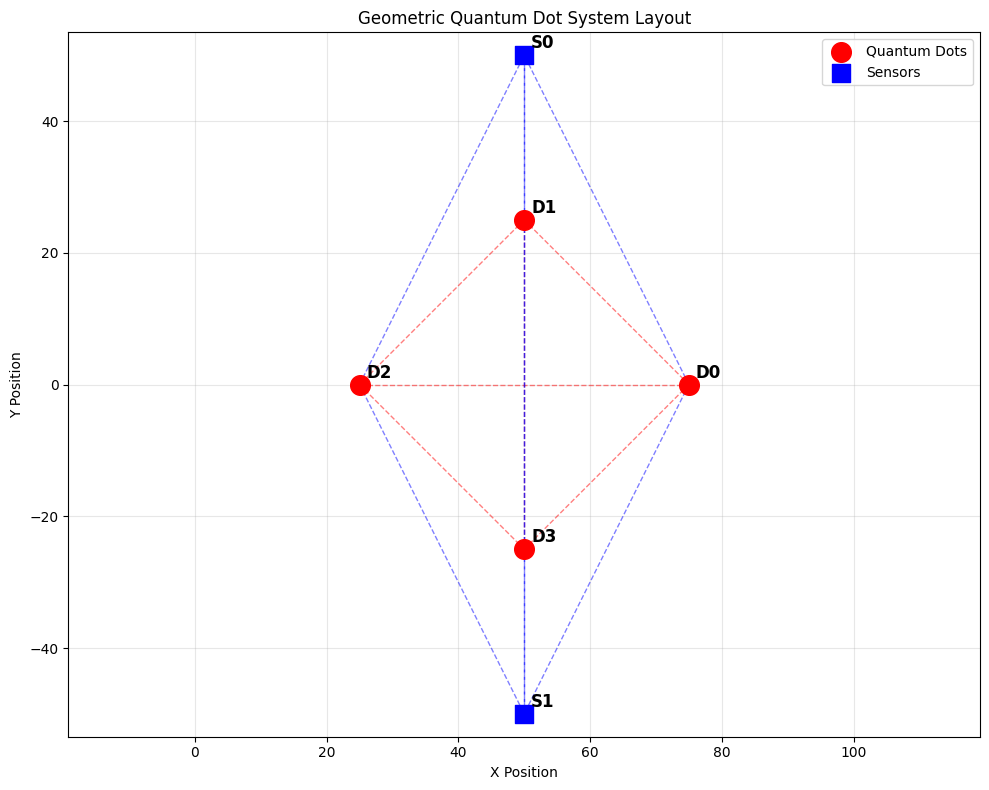


Complex system coupling information:
  Average dot-dot coupling: 7.41e-16 F
  Average dot-sensor coupling: 6.16e-16 F
  Max coupling strength: 0.681
  Min coupling strength: 0.585


In [5]:
print(f"Created complex geometric system: {geo_system}")

# Plot the complex system layout
print("\nPlotting complex system layout...")
geo_system.plot_system(show_capacitances=True, capacitance_threshold=0.005)

# Get coupling information for complex system
coupling_info_2 = geo_system.get_coupling_info()
print(f"\nComplex system coupling information:")
print(f"  Average dot-dot coupling: {coupling_info_2['avg_dot_dot_coupling']:.2e} F")
print(f"  Average dot-sensor coupling: {coupling_info_2['avg_dot_sensor_coupling']:.2e} F")
print(f"  Max coupling strength: {coupling_info_2['max_coupling']:.3f}")
print(f"  Min coupling strength: {coupling_info_2['min_coupling']:.3f}")

In [6]:
# Integration with full simulator
print("\n\nIntegrating with full ReadSpyn simulator...")

# Use the first geometric system for simulation
dot_system = geo_system.dot_system

print(f"Using geometric system: {dot_system.num_dots} dots, {dot_system.num_sensors} sensors")

# Configure sensor parameters
params_resonator = {
    'Lc': 800e-9,      # Inductance (H)
    'Cp': 0.5e-12,     # Parasitic capacitance (F)
    'RL': 40,          # Load resistance (Ω)
    'Rc': 100e6,       # Coupling resistance (Ω)
    'Z0': 50           # Characteristic impedance (Ω)
}

params_coulomb_peak = {
    'g0': 1/50,        # Maximum conductance (S)
    'eps0': 0.5,       # Operating point (relative to eps_width)
    'eps_width': 1.0   # Energy width (eV)
}


params_coulomb_peak_2 = {
    'g0': 1/50,        # Maximum conductance (S)
    'eps0': 0.25,       # Operating point (relative to eps_width)
    'eps_width': 1.0   # Energy width (eV)
}


# Noise models
#    - circuit noise (independent, very small here)
c_noise = OU_noise(sigma=1.5e-10, gamma=1e4)
c_noise_2 = OU_noise(sigma=1.0e-10, gamma=1e4)

#    - base eps noise per sensor (we'll correlate these across sensors via CorrelatedNoise)
base_eps_noise = OU_noise(sigma=0.25e-1, gamma=1e2)   # gamma = 1/tc, tc = 1e-2 s here

sensor1 = RLC_sensor(params_resonator, params_coulomb_peak, c_noise)
sensor2 =  RLC_sensor(params_resonator, params_coulomb_peak, c_noise) # RLC_sensor(params_resonator, params_coulomb_peak_2, c_noise_2)

sensors = [sensor1, sensor2]

print(f"Sensor 1 resonant frequency: {sensor1.f0/1e9:.2f} GHz")
print(f"Sensor 2 resonant frequency: {sensor2.f0/1e9:.2f} GHz")

correlation_matrix = jnp.array([
    [1.0, 0.7],
    [0.7, 1.0]
])
correlated_eps_noise = CorrelatedNoise(base_eps_noise, correlation_matrix)


# Create simulator
simulator = JAXReadoutSimulator(dot_system, sensors) #what happend here?

# Define charge states to simulate
charge_states = jnp.array([
    [0, 1, 1, 0],  
    [0, 0, 2, 0],
    # [0, 0, 1, 0],
    # [0, 0, 0, 1],
])
    
results_dict = {}
# Define simulation parameters
t_end = 20e-6  # 1 μs absolute end time
dt = 5.e-9   # 0.5 ns time step
times = jnp.arange(0, t_end, dt)



Integrating with full ReadSpyn simulator...
Using geometric system: 4 dots, 2 sensors
[RLC_sensor] Initialized with:
  Lc = 8.000e-07 H
  Cp = 5.000e-13 F
  Self-capacitance = 0.000e+00 F
  Total capacitance = 5.000e-13 F
  RL = 40 Ω
  Rc = 1.000e+08 Ω
  Z0 = 50 Ω
  R0 = 5.000e+01 Ω
  g0 = 2.000e-02 S
  eps_w = 1.000e+00 eV
  Resonant frequency = 2.516e+08 Hz
  Resonant period = 3.974e-09 s
  Capacitance noise model: OU_noise
  Energy noise model: None
[RLC_sensor] Initialized with:
  Lc = 8.000e-07 H
  Cp = 5.000e-13 F
  Self-capacitance = 0.000e+00 F
  Total capacitance = 5.000e-13 F
  RL = 40 Ω
  Rc = 1.000e+08 Ω
  Z0 = 50 Ω
  R0 = 5.000e+01 Ω
  g0 = 2.000e-02 S
  eps_w = 1.000e+00 eV
  Resonant frequency = 2.516e+08 Hz
  Resonant period = 3.974e-09 s
  Capacitance noise model: OU_noise
  Energy noise model: None
Sensor 1 resonant frequency: 0.25 GHz
Sensor 2 resonant frequency: 0.25 GHz


In [7]:
# Parameter settings 2
n_realizations = 1000

snr = 4
params = {
        'eps0': 0.1, 
        'snr': snr,
        't_end': t_end
    }

key, subkey = jax.random.split(key)
simulator.precompute_noise(subkey, times, n_realizations, correlated_eps_noise)

Precomputing 1000 noise trajectory segments...
Using correlated noise for 2 sensors
Noise trajectory segments precomputed successfully.


In [8]:
key, subkey = jax.random.split(key)
results = simulator.run_simulation(charge_states, times, params, subkey)

Running simulation for 2 charge states with 1000 realizations...
Processing sensor 0...
Sensor 0: Average separation = 0.000002
Processing sensor 1...
Sensor 1: Average separation = 0.000001
Simulation completed successfully.


Sensor 0 fidelity: 0.838
Sensor 1 fidelity: 0.7324999999999999


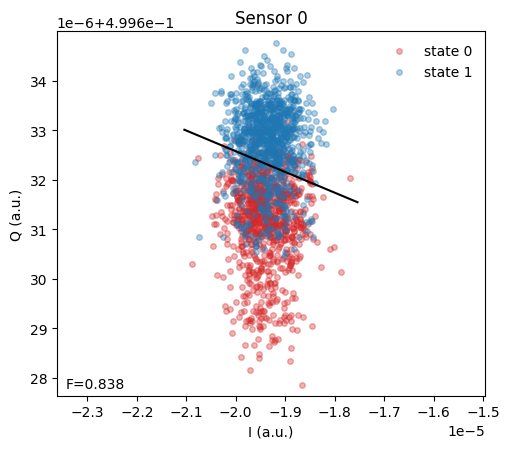

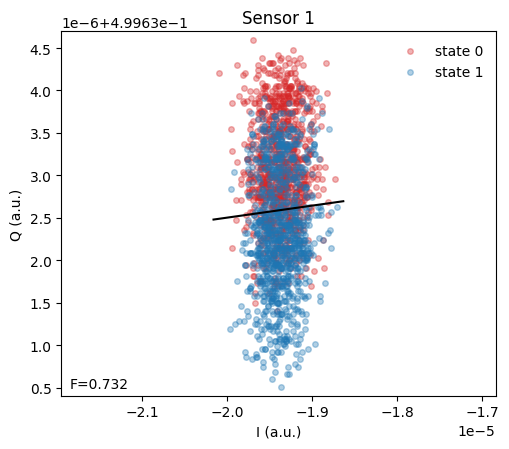

In [9]:
# Sensor 0
fig0, ax0, res0 = plot_and_threshold_sensor(results, sensor_idx=0,
                                            use_cummean=True, demean=False, zscore=False)
print("Sensor 0 fidelity:", res0['fidelity'])

# Sensor 1
fig1, ax1, res1 = plot_and_threshold_sensor(results, sensor_idx=1,
                                            use_cummean=True, demean=False, zscore=False)
print("Sensor 1 fidelity:", res1['fidelity'])


## Add rotation of qubits (tests)

In [10]:
rotated = rotate_dot_positions(dot_positions, angle_deg=30.0)  # around (50, 0)

Dot-sensor coupling strength (Δε/ε_w): [[0.62000398 0.59516517 0.6628472  0.67470182]
 [0.6628472  0.67470182 0.62000398 0.59516517]]


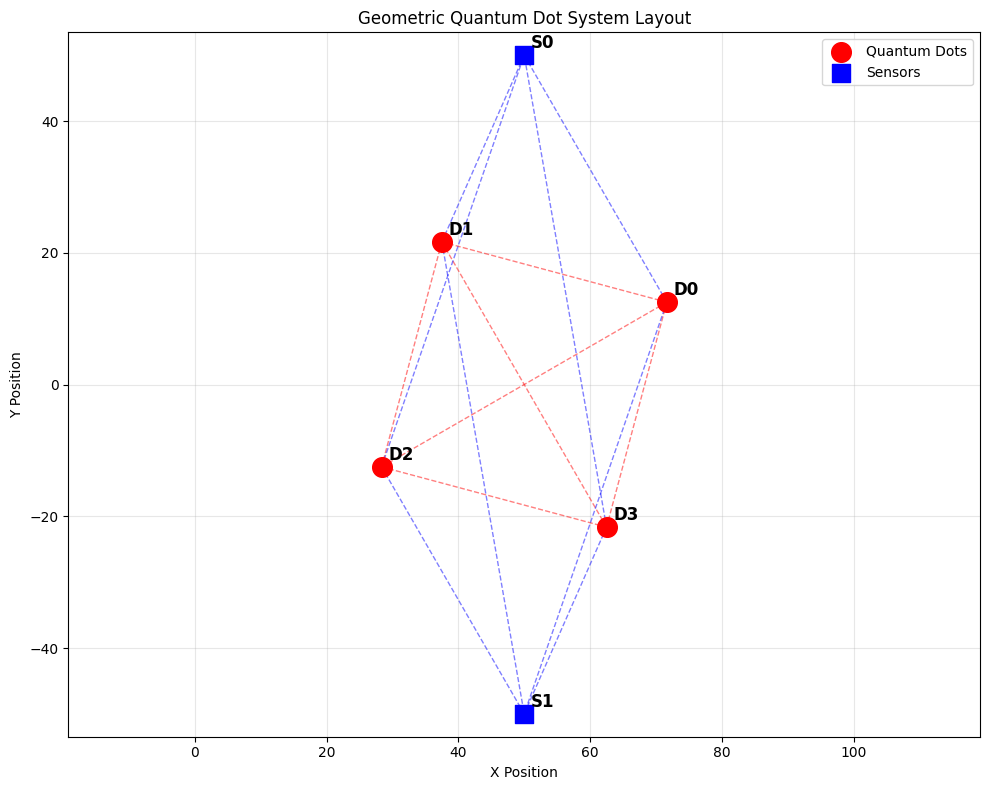

In [11]:
# Create geometric system with different parameters
geo_system = GeometricQuantumDotSystem(
    dot_positions=rotated,
    sensor_positions=sensor_positions,
    C0=1e-15,      # Base capacitance: 1 fF
    alpha=0.8,     # Stronger coupling
    beta=0.005     # Longer range coupling
)

geo_system.plot_system(show_capacitances=True, capacitance_threshold=0.005)

In [12]:

dot_system = geo_system.dot_system

# Create simulator
simulator = JAXReadoutSimulator(dot_system, sensors) #what happend here?

# Define charge states to simulate --> use previous charge states
# charge_states = jnp.array([
#     [0, 0, 2, 0],  
#     [0, 0, 1, 1],
#     #[0, 0, 1, 0],
#    # [0, 0, 0, 1],
# ])
    
results_dict = {}
# Define simulation parameters
t_end = 20e-6  # 1 μs absolute end time
dt = 5.e-9   # 0.5 ns time step
times = jnp.arange(0, t_end, dt)

In [13]:
n_realizations = 1000

snr = 4
params = {
        'eps0': 0.1, 
        'snr': snr,
        't_end': t_end
    }

key, subkey = jax.random.split(key)
simulator.precompute_noise(subkey, times, n_realizations, correlated_eps_noise)

key, subkey = jax.random.split(key)
results = simulator.run_simulation(charge_states, times, params, subkey)

Precomputing 1000 noise trajectory segments...
Using correlated noise for 2 sensors
Noise trajectory segments precomputed successfully.
Running simulation for 2 charge states with 1000 realizations...
Processing sensor 0...
Sensor 0: Average separation = 0.000002
Processing sensor 1...
Sensor 1: Average separation = 0.000002
Simulation completed successfully.


Sensor 0 fidelity: 0.955
Sensor 1 fidelity: 0.9395


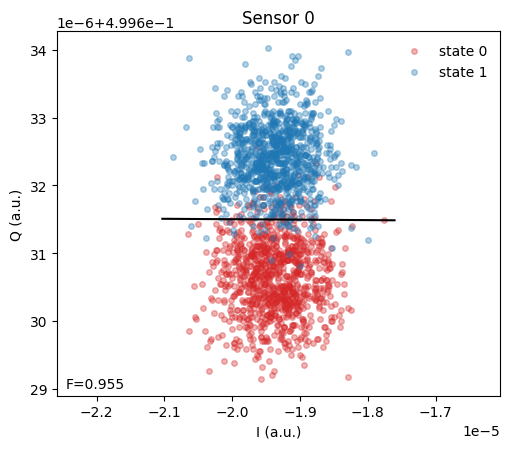

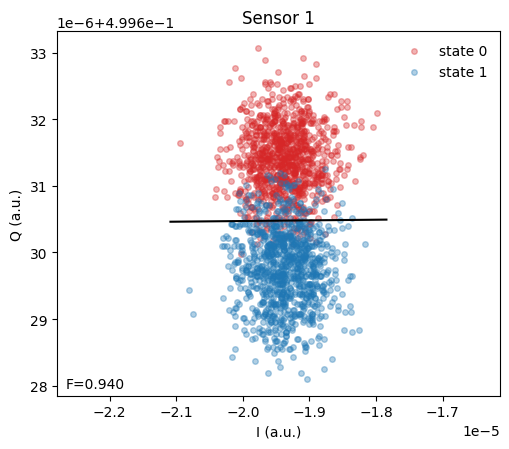

In [14]:
# Sensor 0
fig0, ax0, res0 = plot_and_threshold_sensor(results, sensor_idx=0,
                                            use_cummean=True, demean=False, zscore=False)
print("Sensor 0 fidelity:", res0['fidelity'])

# Sensor 1
fig1, ax1, res1 = plot_and_threshold_sensor(results, sensor_idx=1,
                                            use_cummean=True, demean=False, zscore=False)
print("Sensor 1 fidelity:", res1['fidelity'])


## All together

Dot-sensor coupling strength (Δε/ε_w): [[0.64627219 0.58477881 0.64627219 0.68099704]
 [0.64627219 0.68099704 0.64627219 0.58477881]]
[RLC_sensor] Initialized with:
  Lc = 8.000e-07 H
  Cp = 5.000e-13 F
  Self-capacitance = 0.000e+00 F
  Total capacitance = 5.000e-13 F
  RL = 40 Ω
  Rc = 1.000e+08 Ω
  Z0 = 50 Ω
  R0 = 5.000e+01 Ω
  g0 = 2.000e-02 S
  eps_w = 1.000e+00 eV
  Resonant frequency = 2.516e+08 Hz
  Resonant period = 3.974e-09 s
  Capacitance noise model: OU_noise
  Energy noise model: None
[RLC_sensor] Initialized with:
  Lc = 8.000e-07 H
  Cp = 5.000e-13 F
  Self-capacitance = 0.000e+00 F
  Total capacitance = 5.000e-13 F
  RL = 40 Ω
  Rc = 1.000e+08 Ω
  Z0 = 50 Ω
  R0 = 5.000e+01 Ω
  g0 = 2.000e-02 S
  eps_w = 1.000e+00 eV
  Resonant frequency = 2.516e+08 Hz
  Resonant period = 3.974e-09 s
  Capacitance noise model: OU_noise
  Energy noise model: None
Precomputing 1000 noise trajectory segments...
Using correlated noise for 2 sensors
Noise trajectory segments precomputed su

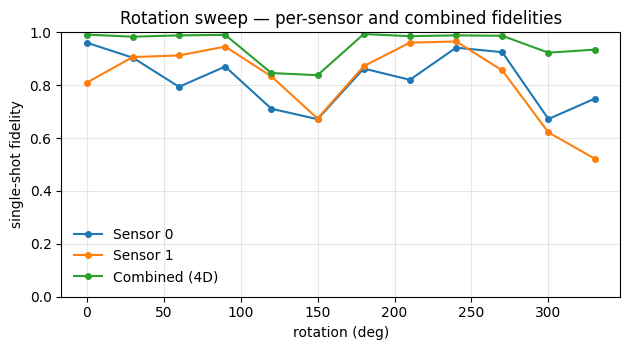

In [15]:
# Define the sweep and states
snr = 4.0

t_end = 20e-6  # 1 μs absolute end time
dt = 5.e-9   # 0.5 ns time step
times = jnp.arange(0, t_end, dt)

params = {
        'eps0': 0.1, 
        'snr': snr,
        't_end': t_end
    }

N_steps  = 12
angles   = np.linspace(0, 360, N_steps, endpoint=False)
state_A  = [0, 1, 1, 0]  
state_B  = [0, 0, 2, 0]  

key = jax.random.PRNGKey(123)
f0, f1, fc = benchmark_rotation_fidelity_multi(
    lambda dp, ang: simulator_factory(dp, ang, center=(50.0, 0.0)),
    dot_positions, angles,
    state_A, state_B,
    times, params, correlated_eps_noise,
    n_realizations=1000, key=key
)

# Plot
plot_rotation_fidelity_multi(angles, f0, f1, fc,
    title='Rotation sweep — per-sensor and combined fidelities')
plt.show()


## Visualization


Plotting rotation snapshots with shifted sensor positions...


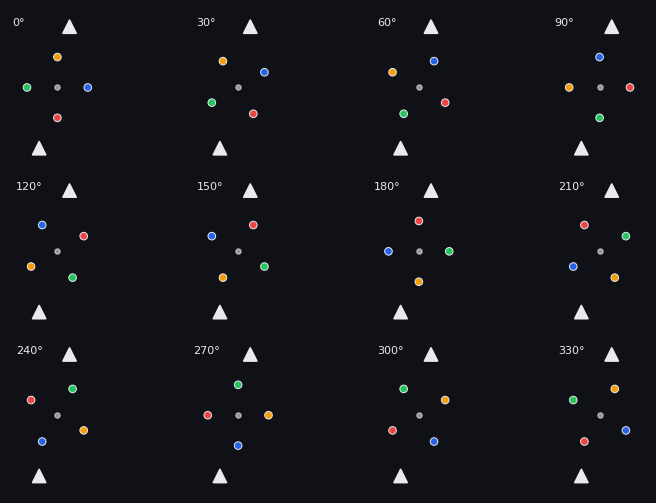

In [16]:
sensor_positions = np.array([[50.0,  50.0],
                             [50.0, -50.0]])

# Shift top sensor +10 nm, bottom sensor -15 nm (units match your coordinates)
sensor_positions2 = shift_sensor_positions_x(sensor_positions, dx=[10.0, -15.0])

# Or shift both by +5:
sensor_positions3 = shift_sensor_positions_x(sensor_positions, dx=5.0)

print("\nPlotting rotation snapshots with shifted sensor positions...")
angles = np.arange(0, 360, 30)
fig, axes = plot_rotation_snapshots(
    dot_positions, sensor_positions2, angles,
    center=(50.0, 0.0), ncols=4, figsize=(8, 5),
    theme='dark', show_labels=False, show_pivot=True,
    dot_size=30, sensor_size=90, lw=1.2
)
plt.show()




# Combine all here

In [17]:
snr = 4.0

t_end = 50e-6  # 1 μs absolute end time
dt = 5.e-9   # 0.5 ns time step
times = jnp.arange(0, t_end, dt)

params = {
        'eps0': 0.1, 
        'snr': snr,
        't_end': t_end
    }

N_steps  = 12
angles   = np.linspace(0, 360, N_steps, endpoint=False)
state_A  = [0, 1, 1, 0]  
state_B  = [0, 0, 2, 0]  


Dot-sensor coupling strength (Δε/ε_w): [[0.57997345 0.61605094 0.66560812 0.64732585]
 [0.66560812 0.64732585 0.57997345 0.61605094]]
[RLC_sensor] Initialized with:
  Lc = 8.000e-07 H
  Cp = 5.000e-13 F
  Self-capacitance = 0.000e+00 F
  Total capacitance = 5.000e-13 F
  RL = 40 Ω
  Rc = 1.000e+08 Ω
  Z0 = 50 Ω
  R0 = 5.000e+01 Ω
  g0 = 2.000e-02 S
  eps_w = 1.000e+00 eV
  Resonant frequency = 2.516e+08 Hz
  Resonant period = 3.974e-09 s
  Capacitance noise model: OU_noise
  Energy noise model: None
[RLC_sensor] Initialized with:
  Lc = 8.000e-07 H
  Cp = 5.000e-13 F
  Self-capacitance = 0.000e+00 F
  Total capacitance = 5.000e-13 F
  RL = 40 Ω
  Rc = 1.000e+08 Ω
  Z0 = 50 Ω
  R0 = 5.000e+01 Ω
  g0 = 2.000e-02 S
  eps_w = 1.000e+00 eV
  Resonant frequency = 2.516e+08 Hz
  Resonant period = 3.974e-09 s
  Capacitance noise model: OU_noise
  Energy noise model: None
Precomputing 1000 noise trajectory segments...
Using correlated noise for 2 sensors
Noise trajectory segments precomputed su

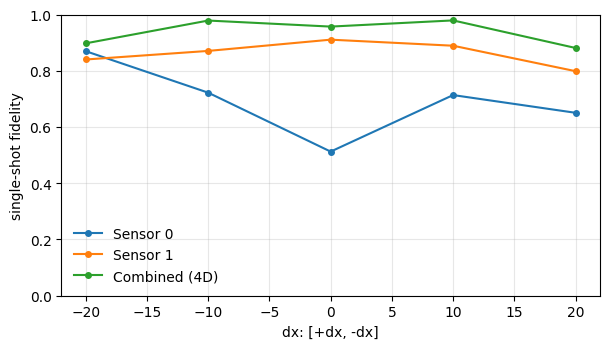

In [18]:
# 1) Symmetric sweep: sensor0 +dx, sensor1 -dx (at current rotation angle)
dx_vals = np.linspace(-20.0, 20.0, 5)
f0, f1, fc = sweep_sensor_shift_symmetric(
    dot_positions, sensor_positions, dx_vals,
    state_A, state_B,
    times, params, correlated_eps_noise,
    angle_deg=90.0, n_realizations=1000, key=jax.random.PRNGKey(123)
)
plot_sensor_shift_curves(dx_vals, f0, f1, fc, xlabel='dx: [+dx, -dx]')

In [20]:
# # 2) 2D grid over (dx0, dx1) for the same angle
# dx0_vals = np.linspace(-30.0, 30.0, 5)
# dx1_vals = np.linspace(-30.0, 30.0, 5)
# F0, F1, FC = sweep_sensor_shift_grid(
#     dot_positions, sensor_positions, dx0_vals, dx1_vals,
#     state_A, state_B,
#     times, params, correlated_eps_noise,
#     angle_deg=0.0, n_realizations=100, key=jax.random.PRNGKey(456)
# )
# plot_sensor_shift_heatmaps(dx0_vals, dx1_vals, F0, F1, FC)
# # plt.show()


## Sweep over angels and sensor positions (3D plots)

In [21]:
angles = np.linspace(0, 180, 18, endpoint=True)   
dx_vals = np.linspace(-50.0, 50.0, 10)

key = jax.random.PRNGKey(123)
F0, F1, FC = sweep_rotation_and_shift(
    dot_positions, sensor_positions, angles, dx_vals,
    state_A, state_B,
    build_simulator,
    times, params, correlated_eps_noise,
    n_realizations=500, key=key
)

Dot-sensor coupling strength (Δε/ε_w): [[0.60759738 0.5489571  0.5489571  0.60759738]
 [0.5489571  0.60759738 0.60759738 0.5489571 ]]
[RLC_sensor] Initialized with:
  Lc = 8.000e-07 H
  Cp = 5.000e-13 F
  Self-capacitance = 0.000e+00 F
  Total capacitance = 5.000e-13 F
  RL = 40 Ω
  Rc = 1.000e+08 Ω
  Z0 = 50 Ω
  R0 = 5.000e+01 Ω
  g0 = 2.000e-02 S
  eps_w = 1.000e+00 eV
  Resonant frequency = 2.516e+08 Hz
  Resonant period = 3.974e-09 s
  Capacitance noise model: OU_noise
  Energy noise model: None
[RLC_sensor] Initialized with:
  Lc = 8.000e-07 H
  Cp = 5.000e-13 F
  Self-capacitance = 0.000e+00 F
  Total capacitance = 5.000e-13 F
  RL = 40 Ω
  Rc = 1.000e+08 Ω
  Z0 = 50 Ω
  R0 = 5.000e+01 Ω
  g0 = 2.000e-02 S
  eps_w = 1.000e+00 eV
  Resonant frequency = 2.516e+08 Hz
  Resonant period = 3.974e-09 s
  Capacitance noise model: OU_noise
  Energy noise model: None
Precomputing 500 noise trajectory segments...
Using correlated noise for 2 sensors
Noise trajectory segments precomputed suc

(<Figure size 740x480 with 2 Axes>,
 <Axes3D: title={'center': 'Sensor 1 fidelity surface'}, xlabel='dx (sensor0 +dx, sensor1 -dx)', ylabel='rotation (deg)', zlabel='fidelity'>)

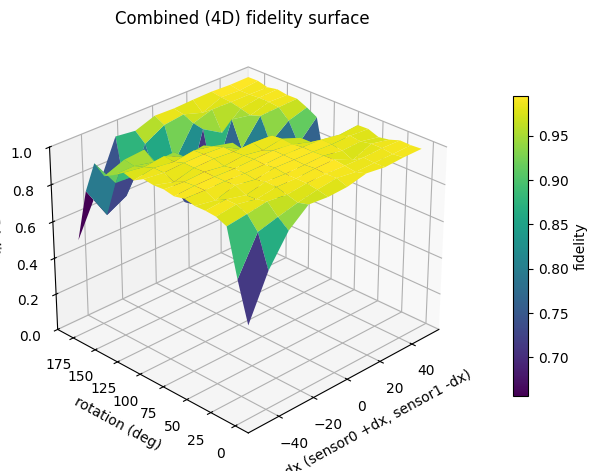

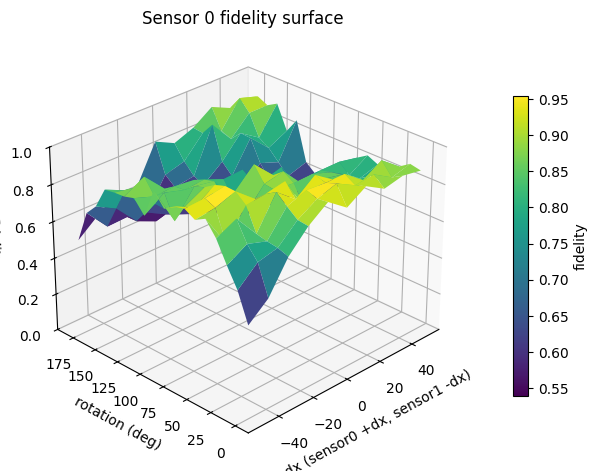

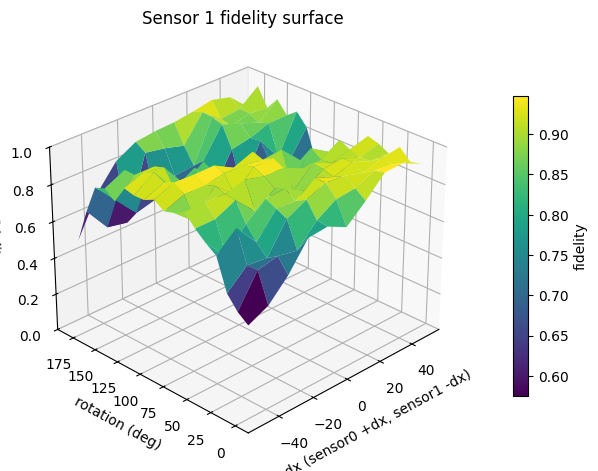

In [22]:
# 3D surface of combined (4D) fidelity
plot_fidelity_surface_3d(angles, dx_vals, FC, title='Combined (4D) fidelity surface')
# per-sensor
plot_fidelity_surface_3d(angles, dx_vals, F0, title='Sensor 0 fidelity surface')
plot_fidelity_surface_3d(angles, dx_vals, F1, title='Sensor 1 fidelity surface')
# plt.show()


## Find maximum and visualize

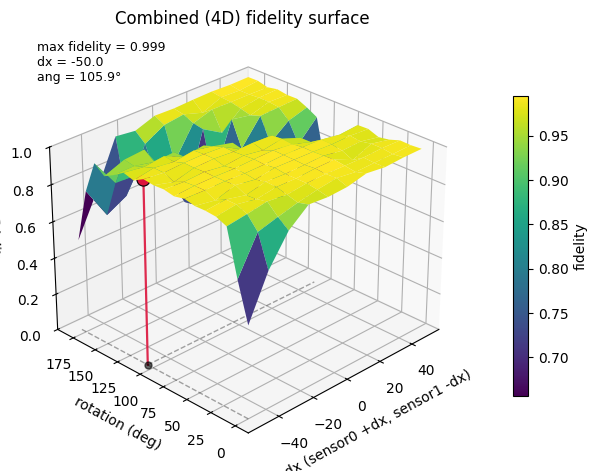

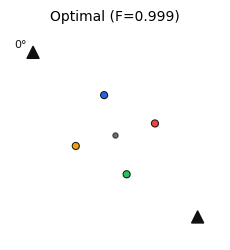

In [23]:
# After you computed the grids and plotted the surface, e.g. for combined FC:
fig, ax = plot_fidelity_surface_3d(angles, dx_vals, FC, title='Combined (4D) fidelity surface')

# Highlight the maximum on the surface
ang_opt, dx_opt, fmax = highlight_max_clean(ax, angles, dx_vals, FC)
plt.show()

# Option B: pinned to corner
# ang_opt, dx_opt, fmax = annotate_max_in_corner(ax, angles, dx_vals, FC)
# plt.show()

# Visualize the optimal layout (rotated dots + shifted sensors)
fig_opt, ax_opt, dots_opt, sensors_opt = visualize_optimal_layout(
    dot_positions, sensor_positions, ang_opt, dx_opt, title=f'Optimal (F={fmax:.3f})'
)
# plt.show()


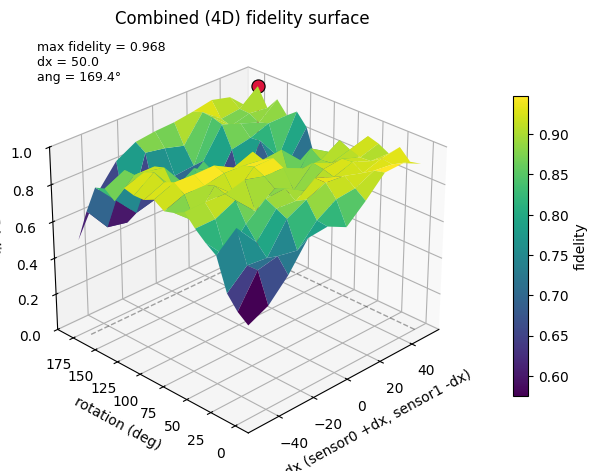

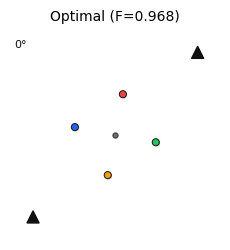

In [24]:
# After you computed the grids and plotted the surface, e.g. for combined FC:
fig, ax = plot_fidelity_surface_3d(angles, dx_vals, F1, title='Combined (4D) fidelity surface')

# Highlight the maximum on the surface
ang_opt, dx_opt, fmax = highlight_max_clean(ax, angles, dx_vals, F1)
plt.show()

# Visualize the optimal layout (rotated dots + shifted sensors)
fig_opt, ax_opt, dots_opt, sensors_opt = visualize_optimal_layout(
    dot_positions, sensor_positions, ang_opt, dx_opt, title=f'Optimal (F={fmax:.3f})'
)
# plt.show()


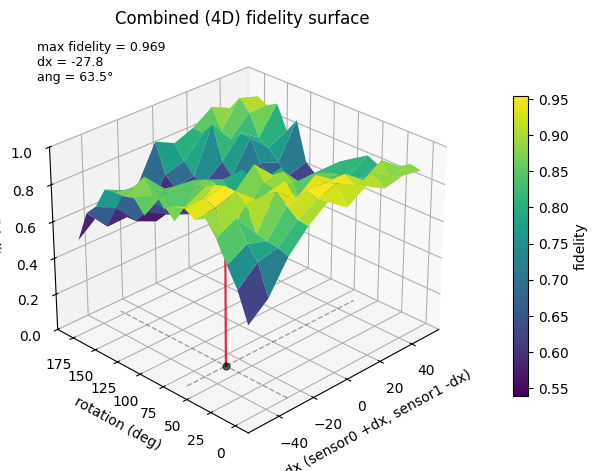

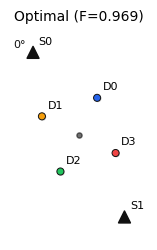

In [25]:
# After you computed the grids and plotted the surface, e.g. for combined FC:
fig, ax = plot_fidelity_surface_3d(angles, dx_vals, F0, title='Combined (4D) fidelity surface')

# Highlight the maximum on the surface
ang_opt, dx_opt, fmax = highlight_max_clean(ax, angles, dx_vals, F0)
plt.show()

# Visualize the optimal layout (rotated dots + shifted sensors)
fig_opt, ax_opt, dots_opt, sensors_opt = visualize_optimal_layout(
    dot_positions, sensor_positions, ang_opt, dx_opt, title=f'Optimal (F={fmax:.3f})'
)
label_dots_and_sensors(ax_opt, dots_opt, sensors_opt)   # <- add labels

# plt.show()
